Loaded 1332997 rows with columns: ['date', 'lat', 'lng', 'subject_age', 'outcome_encd', 'race_asian/pacific islander', 'race_black', 'race_hispanic', 'race_other', 'race_unknown', 'race_white', 'sex_female', 'sex_male', 'WealthIndex', 'subject_race', 'subject_sex', 'year', 'age_c', 'wealth_c', 'cluster_id']
infer_df columns: ['date', 'lat', 'lng', 'subject_age', 'outcome_encd', 'race_asian/pacific islander', 'race_black', 'race_hispanic', 'race_other', 'race_unknown', 'race_white', 'sex_female', 'sex_male', 'WealthIndex', 'subject_race', 'subject_sex', 'year', 'age_c', 'wealth_c', 'cluster_id']
Modeling pipeline complete.
Train years: [2013, 2014, 2015]
Test years: [2016]
Spline on age used: True
Spline on wealth used: False
Held-out accuracy: 0.7893
Held-out macro F1: 0.2941
Held-out balanced accuracy: 0.3333
Held-out log loss: 0.5668
Majority-class baseline accuracy: 0.7893

Saved outputs to: data_modeling_updated/model_outputs

Top recommendations:
- Age shows evidence of nonlineari

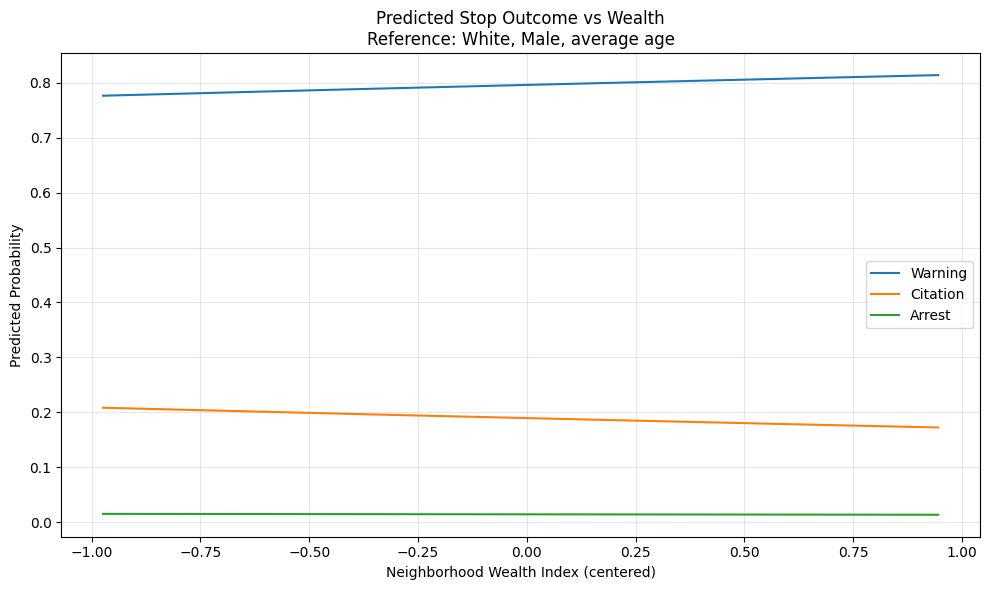

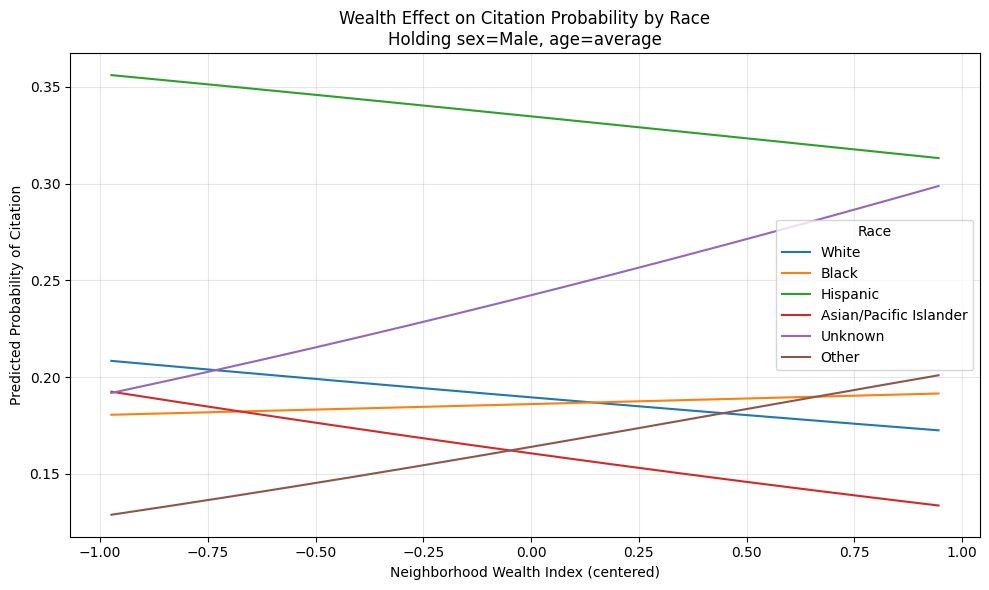

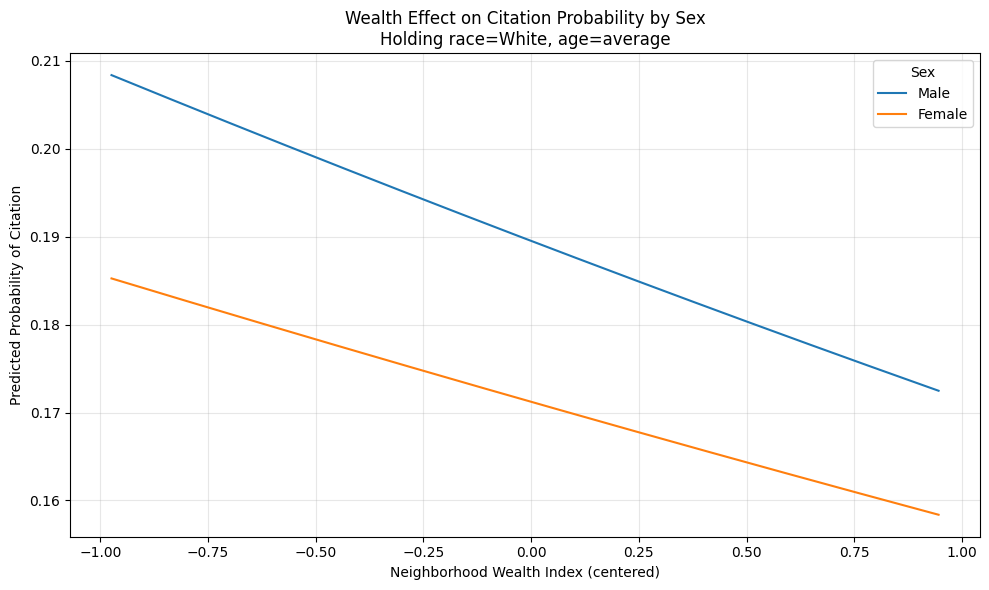

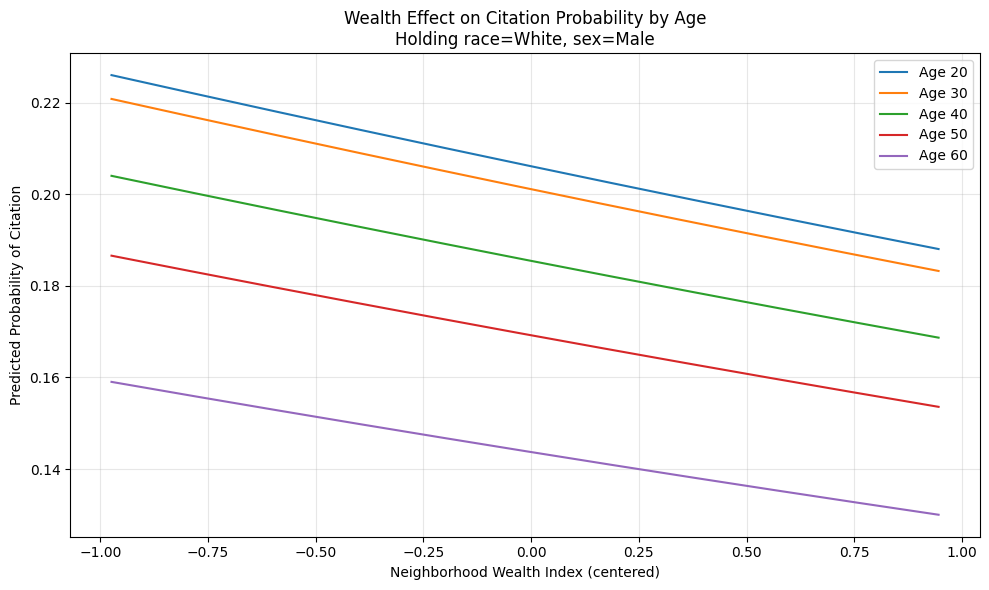


Marginal effect of WealthIndex on predicted probabilities:
    Outcome  MarginalEffect
0   Warning        0.019433
1  Citation       -0.018610
2    Arrest       -0.000824


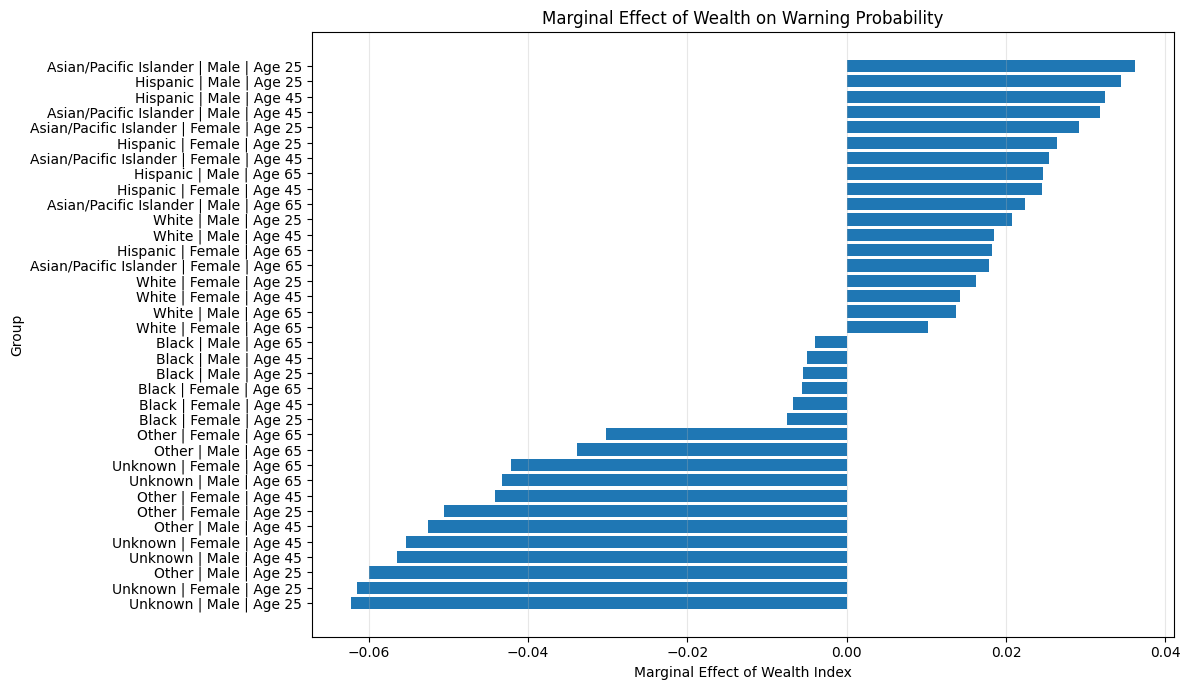

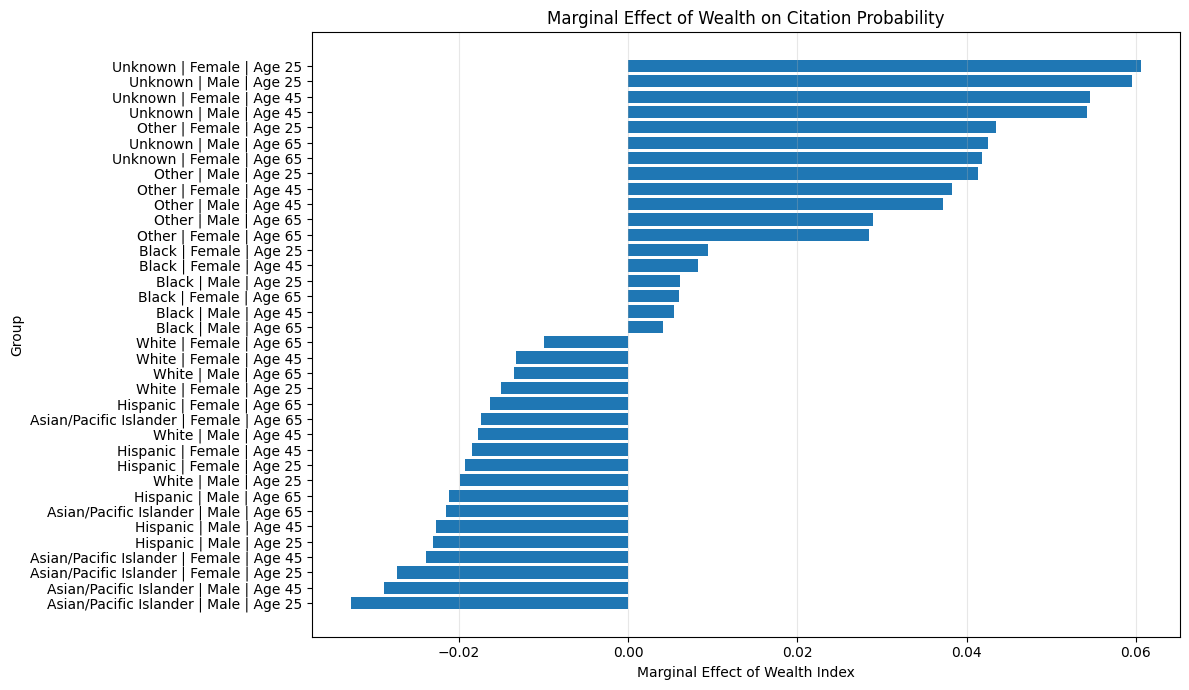

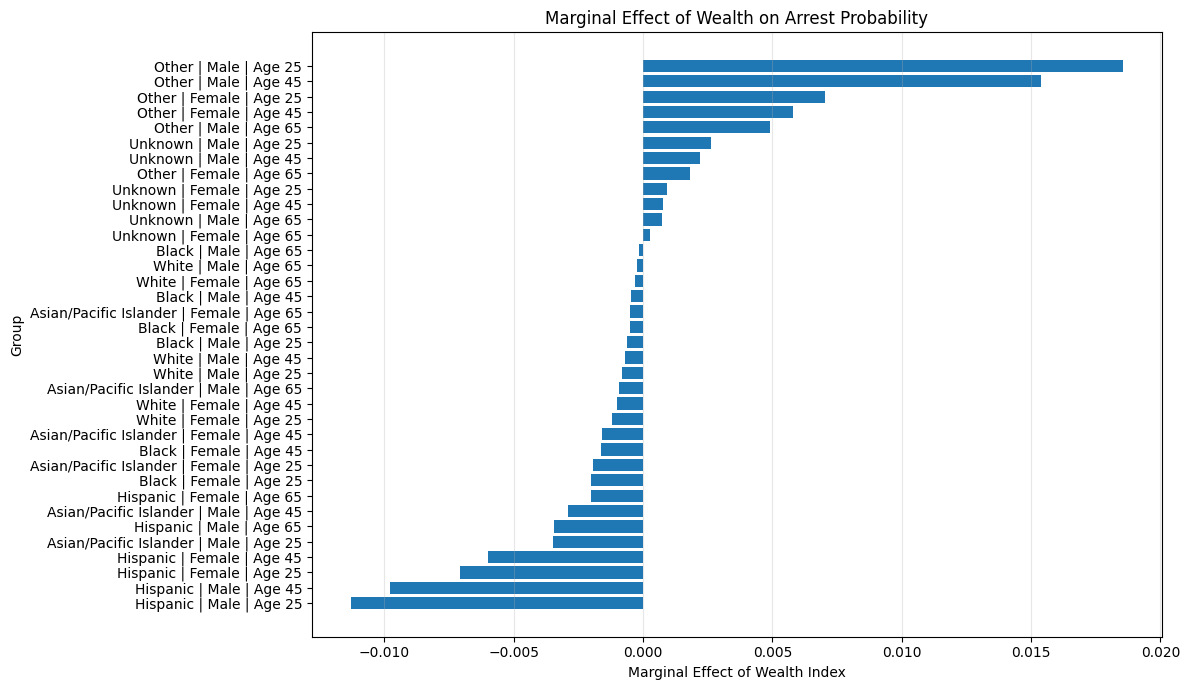

In [ ]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from patsy import build_design_matrices, dmatrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.formula.api import logit
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
DATA_PATH = Path("main_df_final_with_wealth_past_only.csv")
OUTPUT_DIR = Path("data_modeling_updated/model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTCOME_LABELS = {
    1: "Warning",
    2: "Citation",
    3: "Arrest",
}

RACE_LEVELS = [
    "White",
    "Black",
    "Hispanic",
    "Asian/Pacific Islander",
    "Unknown",
    "Other",
]

SEX_LEVELS = [
    "Male",
    "Female",
]

RACE_DUMMY_TO_LABEL = {
    "race_white": "White",
    "race_black": "Black",
    "race_hispanic": "Hispanic",
    "race_asian/pacific islander": "Asian/Pacific Islander",
    "race_unknown": "Unknown",
    "race_other": "Other",
}

SEX_DUMMY_TO_LABEL = {
    "sex_male": "Male",
    "sex_female": "Female",
}

OUTCOME_NAMES = ["Warning", "Citation", "Arrest"]

TRAIN_YEARS = [2013, 2014, 2015]
TEST_YEARS = [2016]
INFERENCE_SAMPLE_N = 75000
DIAGNOSTIC_SAMPLE_N = 30000
RANDOM_STATE = 42


@dataclass
class AssumptionReport:
    missingness: Dict[str, float]
    class_balance: Dict[str, float]
    zero_count_race_sex_cells: int
    max_vif: float
    vif_table: Dict[str, float]
    age_nonlinearity_flag: bool
    wealth_nonlinearity_flag: bool
    linearity_details: Dict[str, Dict[str, float]]
    iia_relative_change: Dict[str, float]
    iia_flag: bool
    independence_note: str
    recommendations: List[str]


# -----------------------------------------------------------------------------
# Load + preprocess
# -----------------------------------------------------------------------------
def load_data(path: Path = DATA_PATH) -> pd.DataFrame:
    usecols = [
        "date",
        "lat",
        "lng",
        "subject_age",
        "outcome_encd",
        "race_white",
        "race_black",
        "race_hispanic",
        "race_asian/pacific islander",
        "race_unknown",
        "race_other",
        "sex_male",
        "sex_female",
        "WealthIndex",
    ]
    df = pd.read_csv(path, usecols=usecols, parse_dates=["date"])

    df = df.dropna(
        subset=[
            "subject_age",
            "outcome_encd",
            "WealthIndex",
            "date",
            "lat",
            "lng",
            "race_white",
            "race_black",
            "race_hispanic",
            "race_asian/pacific islander",
            "race_unknown",
            "race_other",
            "sex_male",
            "sex_female",
        ]
    ).copy()

    # Ensure numeric dummy columns
    race_dummy_cols = list(RACE_DUMMY_TO_LABEL.keys())
    sex_dummy_cols = list(SEX_DUMMY_TO_LABEL.keys())

    for col in race_dummy_cols + sex_dummy_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Require exactly one active race dummy and one active sex dummy
    race_sum = df[race_dummy_cols].sum(axis=1)
    sex_sum = df[sex_dummy_cols].sum(axis=1)
    df = df[(race_sum == 1) & (sex_sum == 1)].copy()

    # Reconstruct categorical race / sex variables
    df["subject_race"] = df[race_dummy_cols].idxmax(axis=1).map(RACE_DUMMY_TO_LABEL)
    df["subject_sex"] = df[sex_dummy_cols].idxmax(axis=1).map(SEX_DUMMY_TO_LABEL)

    # Explicit categorical ordering so White and Male become the reference groups
    df["subject_race"] = pd.Categorical(df["subject_race"], categories=RACE_LEVELS)
    df["subject_sex"] = pd.Categorical(df["subject_sex"], categories=SEX_LEVELS)

    # Basic type cleanup
    df["outcome_encd"] = pd.to_numeric(df["outcome_encd"], errors="coerce")
    df = df[df["outcome_encd"].isin([1, 2, 3])].copy()
    df["outcome_encd"] = df["outcome_encd"].astype(int)

    df["subject_age"] = pd.to_numeric(df["subject_age"], errors="coerce")
    df["WealthIndex"] = pd.to_numeric(df["WealthIndex"], errors="coerce")
    df = df.dropna(subset=["subject_age", "WealthIndex"]).copy()

    df["year"] = df["date"].dt.year

    # Center continuous predictors for cleaner interactions and lower collinearity
    df["age_c"] = df["subject_age"] - df["subject_age"].mean()
    df["wealth_c"] = df["WealthIndex"] - df["WealthIndex"].mean()

    # Spatial cluster id for cluster-robust standard errors
    df["cluster_id"] = (
        df["year"].astype(str)
        + "_"
        + df["lat"].round(2).astype(str)
        + "_"
        + df["lng"].round(2).astype(str)
    )

    print(f"Loaded {len(df)} rows with columns: {list(df.columns)}")
    return df


# -----------------------------------------------------------------------------
# Model formula helpers
# -----------------------------------------------------------------------------
def build_formula_rhs(use_spline_age: bool, use_spline_wealth: bool) -> str:
    age_term = "bs(age_c, df=4, include_intercept=False)" if use_spline_age else "age_c"
    wealth_term = "bs(wealth_c, df=4, include_intercept=False)" if use_spline_wealth else "wealth_c"

    rhs = (
        f"{wealth_term} + {age_term} "
        f'+ C(subject_race, Treatment(reference="White")) '
        f'+ C(subject_sex, Treatment(reference="Male")) '
        f'+ wealth_c:C(subject_race, Treatment(reference="White")) '
        f'+ wealth_c:C(subject_sex, Treatment(reference="Male"))'
    )
    return rhs


# -----------------------------------------------------------------------------
# Assumption checks
# -----------------------------------------------------------------------------
def missingness_summary(path: Path = DATA_PATH) -> Dict[str, float]:
    cols = [
        "subject_age",
        "outcome_encd",
        "WealthIndex",
        "lat",
        "lng",
        "date",
        "race_white",
        "race_black",
        "race_hispanic",
        "race_asian/pacific islander",
        "race_unknown",
        "race_other",
        "sex_male",
        "sex_female",
    ]
    raw = pd.read_csv(path, usecols=cols)
    return raw.isna().mean().sort_values(ascending=False).round(6).to_dict()


def check_zero_cells(df: pd.DataFrame) -> int:
    ct = pd.crosstab(
        [df["subject_race"], df["subject_sex"]],
        df["outcome_encd"],
    )
    return int((ct == 0).sum().sum())


def check_vif(df: pd.DataFrame, rhs: str, sample_n: int = DIAGNOSTIC_SAMPLE_N) -> Tuple[float, Dict[str, float]]:
    sample = df.sample(min(sample_n, len(df)), random_state=RANDOM_STATE).copy()
    X = dmatrix(rhs, data=sample, return_type="dataframe")
    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns,
    ).sort_values(ascending=False)
    return float(vif.max()), vif.round(4).to_dict()


def _pairwise_box_tidwell(df: pd.DataFrame, positive_class: int, negative_class: int) -> Dict[str, float]:
    tmp = df[df["outcome_encd"].isin([positive_class, negative_class])].copy()
    tmp = tmp.sample(min(DIAGNOSTIC_SAMPLE_N, len(tmp)), random_state=RANDOM_STATE)
    tmp["y"] = (tmp["outcome_encd"] == positive_class).astype(int)

    # Both variables should be positive here, but keep a guard
    tmp = tmp[(tmp["WealthIndex"] > 0) & (tmp["subject_age"] > 0)].copy()

    tmp["wealth_log_term"] = tmp["WealthIndex"] * np.log(tmp["WealthIndex"])
    tmp["age_log_term"] = tmp["subject_age"] * np.log(tmp["subject_age"])

    fitted = logit(
        'y ~ WealthIndex + subject_age + wealth_log_term + age_log_term '
        '+ C(subject_race, Treatment(reference="White")) '
        '+ C(subject_sex, Treatment(reference="Male"))',
        data=tmp,
    ).fit(method="lbfgs", maxiter=300, disp=False)

    return {
        "wealth_log_p": float(fitted.pvalues.get("wealth_log_term", np.nan)),
        "age_log_p": float(fitted.pvalues.get("age_log_term", np.nan)),
    }


def check_linearity(df: pd.DataFrame) -> Tuple[bool, bool, Dict[str, Dict[str, float]]]:
    details = {
        "2_vs_1": _pairwise_box_tidwell(df, positive_class=2, negative_class=1),
        "3_vs_1": _pairwise_box_tidwell(df, positive_class=3, negative_class=1),
    }

    wealth_flag = any(v["wealth_log_p"] < 0.01 for v in details.values() if not np.isnan(v["wealth_log_p"]))
    age_flag = any(v["age_log_p"] < 0.01 for v in details.values() if not np.isnan(v["age_log_p"]))
    return age_flag, wealth_flag, details


def check_iia_sensitivity(df: pd.DataFrame, rhs: str) -> Tuple[Dict[str, float], bool]:
    sample = df.sample(min(20000, len(df)), random_state=RANDOM_STATE).copy()

    X_full = dmatrix(rhs, data=sample, return_type="dataframe")
    y_full = sample.loc[X_full.index, "outcome_encd"].map({1: 0, 2: 1, 3: 2}).to_numpy()

    full_model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    full_model.fit(X_full, y_full)

    restricted = sample[sample["outcome_encd"].isin([1, 2])].copy()
    X_rest = dmatrix(rhs, data=restricted, return_type="dataframe")
    y_rest = (restricted.loc[X_rest.index, "outcome_encd"] == 2).astype(int).to_numpy()

    rest_model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    rest_model.fit(X_rest, y_rest)

    wealth_cols = [c for c in X_full.columns if c == "wealth_c" or c.startswith("bs(wealth_c")]
    changes = {}

    for col in wealth_cols:
        full_idx = list(X_full.columns).index(col)
        rest_idx = list(X_rest.columns).index(col)

        beta_full = float(full_model.coef_[1, full_idx])
        beta_rest = float(rest_model.coef_[0, rest_idx])
        denom = max(abs(beta_rest), 1e-6)
        changes[col] = abs(beta_full - beta_rest) / denom

    iia_flag = any(change > 0.20 for change in changes.values())
    return changes, iia_flag


def build_assumption_report(df: pd.DataFrame) -> Tuple[AssumptionReport, str, bool, bool]:
    age_flag, wealth_flag, linearity = check_linearity(df)
    rhs_for_model = build_formula_rhs(use_spline_age=age_flag, use_spline_wealth=wealth_flag)
    rhs_for_vif = build_formula_rhs(use_spline_age=False, use_spline_wealth=False)

    max_vif, vif_table = check_vif(df, rhs_for_vif)
    iia_changes, iia_flag = check_iia_sensitivity(df, rhs_for_model)

    recommendations: List[str] = []
    if age_flag:
        recommendations.append(
            "Age shows evidence of nonlinearity in the log-odds; model age with a spline rather than a single linear term."
        )
    if wealth_flag:
        recommendations.append(
            "WealthIndex shows evidence of nonlinearity; model wealth with a spline or report a spline-based sensitivity analysis."
        )
    if max_vif >= 5:
        recommendations.append(
            "Potential multicollinearity detected; re-check coding, collapse sparse categories, or simplify interactions."
        )
    if iia_flag:
        recommendations.append(
            "IIA sensitivity check is nontrivial; interpret multinomial logit with caution and consider a nested/ordered alternative only if theory supports it."
        )
    recommendations.append(
        "Independence of observations cannot be guaranteed in stop data; use cluster-robust standard errors and list residual within-area dependence as a limitation."
    )

    report = AssumptionReport(
        missingness=missingness_summary(),
        class_balance=df["outcome_encd"].value_counts(normalize=True).sort_index().round(4).to_dict(),
        zero_count_race_sex_cells=check_zero_cells(df),
        max_vif=round(max_vif, 4),
        vif_table=vif_table,
        age_nonlinearity_flag=age_flag,
        wealth_nonlinearity_flag=wealth_flag,
        linearity_details=linearity,
        iia_relative_change={k: round(v, 4) for k, v in iia_changes.items()},
        iia_flag=iia_flag,
        independence_note=(
            "This is observational stop-level data, so true independence is a design assumption rather than something the data can prove. "
            "The script mitigates this by fitting cluster-robust standard errors using year-by-spatial-cell clusters."
        ),
        recommendations=recommendations,
    )

    return report, rhs_for_model, age_flag, wealth_flag


# -----------------------------------------------------------------------------
# Inference model (statsmodels on a large sample)
# -----------------------------------------------------------------------------
def stratified_sample(df: pd.DataFrame, n: int) -> pd.DataFrame:
    if n >= len(df):
        return df.copy()

    frac = n / len(df)
    sampled = (
        df.groupby("outcome_encd", group_keys=False)
        .sample(frac=frac, random_state=RANDOM_STATE)
        .copy()
    )
    return sampled.reset_index(drop=True)


def relabel_terms(df: pd.DataFrame) -> pd.DataFrame:
    def rename_term(term: str) -> str:
        replacements = {
            'C(subject_race, Treatment(reference="White"))[T.Black]': "Black",
            'C(subject_race, Treatment(reference="White"))[T.Hispanic]': "Hispanic",
            'C(subject_race, Treatment(reference="White"))[T.Asian/Pacific Islander]': "Asian/Pacific Islander",
            'C(subject_race, Treatment(reference="White"))[T.Unknown]': "Unknown",
            'C(subject_race, Treatment(reference="White"))[T.Other]': "Other",
            'C(subject_sex, Treatment(reference="Male"))[T.Female]': "Female",
        }
        for old, new in replacements.items():
            term = term.replace(old, new)
        return term

    df.index = [rename_term(idx) for idx in df.index]
    return df


def fit_inference_model(train_df: pd.DataFrame, rhs: str):
    infer_df = stratified_sample(train_df, INFERENCE_SAMPLE_N).copy()
    print("infer_df columns:", list(infer_df.columns))

    y_series = infer_df["outcome_encd"].map({1: 0, 2: 1, 3: 2})
    X = dmatrix(rhs, data=infer_df, return_type="dataframe")
    y_series = y_series.loc[X.index]

    model = MNLogit(y_series, X)
    result = model.fit(
        method="lbfgs",
        maxiter=300,
        disp=False,
        cov_type="cluster",
        cov_kwds={"groups": infer_df.loc[X.index, "cluster_id"]},
    )

    coef = relabel_terms(result.params.copy())
    se = relabel_terms(result.bse.copy())
    zvals = coef / se
    pvals = relabel_terms(result.pvalues.copy())

    coef.to_csv(OUTPUT_DIR / "mnlogit_coefficients.csv")
    se.to_csv(OUTPUT_DIR / "mnlogit_cluster_robust_se.csv")
    zvals.to_csv(OUTPUT_DIR / "mnlogit_zvalues.csv")
    pvals.to_csv(OUTPUT_DIR / "mnlogit_pvalues.csv")
    np.exp(coef).to_csv(OUTPUT_DIR / "mnlogit_odds_ratios.csv")

    return result, X.design_info


# -----------------------------------------------------------------------------
# Validation model (same specification, full training data, held-out 2016)
# -----------------------------------------------------------------------------
def _encode_y(series: pd.Series) -> np.ndarray:
    return series.map({1: 0, 2: 1, 3: 2}).to_numpy()


def validate_generalization(train_df: pd.DataFrame, test_df: pd.DataFrame, rhs: str) -> Dict[str, object]:
    X_train = dmatrix(rhs, data=train_df, return_type="dataframe")
    design_info = X_train.design_info
    X_test = build_design_matrices([design_info], test_df, return_type="dataframe")[0]

    y_train = _encode_y(train_df.loc[X_train.index, "outcome_encd"])
    y_test = _encode_y(test_df.loc[X_test.index, "outcome_encd"])

    model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=None,
    )
    model.fit(X_train, y_train)

    pred_class = model.predict(X_test)
    pred_prob = model.predict_proba(X_test)

    majority_class = int(pd.Series(y_train).mode().iloc[0])
    majority_pred = np.repeat(majority_class, len(y_test))
    majority_prob = np.zeros((len(y_test), 3))
    majority_prob[:, majority_class] = 1.0

    metrics = {
        "test_accuracy": float(round(accuracy_score(y_test, pred_class), 4)),
        "test_macro_f1": float(round(f1_score(y_test, pred_class, average="macro"), 4)),
        "test_balanced_accuracy": float(round(balanced_accuracy_score(y_test, pred_class), 4)),
        "test_log_loss": float(round(log_loss(y_test, pred_prob, labels=[0, 1, 2]), 4)),
        "baseline_accuracy": float(round(accuracy_score(y_test, majority_pred), 4)),
        "baseline_log_loss": float(round(log_loss(y_test, majority_prob, labels=[0, 1, 2]), 4)),
        "confusion_matrix": confusion_matrix(y_test, pred_class).tolist(),
        "classification_report": classification_report(y_test, pred_class, output_dict=True),
    }

    with open(OUTPUT_DIR / "validation_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    coef = pd.DataFrame(
        model.coef_,
        columns=X_train.columns,
        index=[f"class_{c}" for c in model.classes_],
    )
    coef.to_csv(OUTPUT_DIR / "validation_model_coefficients.csv")

    return metrics


def _safe_predict_probs(result, design_info, pred_df):
    X_pred = build_design_matrices([design_info], pred_df, return_type="dataframe")[0]
    probs = result.predict(X_pred)

    if isinstance(probs, pd.DataFrame):
        probs = probs.to_numpy()

    return probs


def _reference_profile(df):
    return {
        "wealth_c": 0.0,
        "age_c": 0.0,
        "subject_race": df["subject_race"].mode().iloc[0],
        "subject_sex": df["subject_sex"].mode().iloc[0],
    }


def plot_predicted_probabilities_vs_wealth_clean(result, design_info, df):
    wealth_grid = np.linspace(
        df["wealth_c"].quantile(0.05),
        df["wealth_c"].quantile(0.95),
        200,
    )

    base = _reference_profile(df)

    pred_df = pd.DataFrame({
        "wealth_c": wealth_grid,
        "age_c": base["age_c"],
        "subject_race": base["subject_race"],
        "subject_sex": base["subject_sex"],
    })

    probs = _safe_predict_probs(result, design_info, pred_df)

    race_label = base["subject_race"]
    sex_label = base["subject_sex"]

    plt.figure(figsize=(10, 6))
    for i, outcome in enumerate(OUTCOME_NAMES):
        plt.plot(wealth_grid, probs[:, i], label=outcome)

    plt.xlabel("Neighborhood Wealth Index (centered)")
    plt.ylabel("Predicted Probability")
    plt.title(f"Predicted Stop Outcome vs Wealth\nReference: {race_label}, {sex_label}, average age")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "predicted_probabilities_vs_wealth.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_wealth_effect_by_race_clean(result, design_info, df, focal_outcome="Citation"):
    wealth_grid = np.linspace(
        df["wealth_c"].quantile(0.05),
        df["wealth_c"].quantile(0.95),
        200,
    )

    base = _reference_profile(df)
    outcome_idx = OUTCOME_NAMES.index(focal_outcome)

    plt.figure(figsize=(10, 6))

    for race in df["subject_race"].cat.categories:
        pred_df = pd.DataFrame({
            "wealth_c": wealth_grid,
            "age_c": base["age_c"],
            "subject_race": race,
            "subject_sex": base["subject_sex"],
        })

        probs = _safe_predict_probs(result, design_info, pred_df)
        plt.plot(wealth_grid, probs[:, outcome_idx], label=race)

    base_sex_label = base["subject_sex"]

    plt.xlabel("Neighborhood Wealth Index (centered)")
    plt.ylabel(f"Predicted Probability of {focal_outcome}")
    plt.title(f"Wealth Effect on {focal_outcome} Probability by Race\nHolding sex={base_sex_label}, age=average")
    plt.legend(title="Race")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"wealth_effect_by_race_{focal_outcome.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_wealth_effect_by_sex_clean(result, design_info, df, focal_outcome="Citation"):
    wealth_grid = np.linspace(
        df["wealth_c"].quantile(0.05),
        df["wealth_c"].quantile(0.95),
        200,
    )

    base = _reference_profile(df)
    outcome_idx = OUTCOME_NAMES.index(focal_outcome)

    plt.figure(figsize=(10, 6))

    for sex in df["subject_sex"].cat.categories:
        pred_df = pd.DataFrame({
            "wealth_c": wealth_grid,
            "age_c": base["age_c"],
            "subject_race": base["subject_race"],
            "subject_sex": sex,
        })

        probs = _safe_predict_probs(result, design_info, pred_df)
        plt.plot(wealth_grid, probs[:, outcome_idx], label=sex)

    base_race_label = base["subject_race"]

    plt.xlabel("Neighborhood Wealth Index (centered)")
    plt.ylabel(f"Predicted Probability of {focal_outcome}")
    plt.title(f"Wealth Effect on {focal_outcome} Probability by Sex\nHolding race={base_race_label}, age=average")
    plt.legend(title="Sex")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"wealth_effect_by_sex_{focal_outcome.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_wealth_effect_by_age_clean(result, design_info, df, focal_outcome="Citation"):
    wealth_grid = np.linspace(
        df["wealth_c"].quantile(0.05),
        df["wealth_c"].quantile(0.95),
        200,
    )

    base = _reference_profile(df)
    outcome_idx = OUTCOME_NAMES.index(focal_outcome)
    age_values = [20, 30, 40, 50, 60]
    mean_age = df["subject_age"].mean()

    plt.figure(figsize=(10, 6))

    for age in age_values:
        pred_df = pd.DataFrame({
            "wealth_c": wealth_grid,
            "age_c": age - mean_age,
            "subject_race": base["subject_race"],
            "subject_sex": base["subject_sex"],
        })

        probs = _safe_predict_probs(result, design_info, pred_df)
        plt.plot(wealth_grid, probs[:, outcome_idx], label=f"Age {age}")

    base_race_label = base["subject_race"]
    base_sex_label = base["subject_sex"]

    plt.xlabel("Neighborhood Wealth Index (centered)")
    plt.ylabel(f"Predicted Probability of {focal_outcome}")
    plt.title(f"Wealth Effect on {focal_outcome} Probability by Age\nHolding race={base_race_label}, sex={base_sex_label}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"wealth_effect_by_age_{focal_outcome.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()


def compute_marginal_effect_of_wealth(result, design_info, df, delta=0.1):
    base = _reference_profile(df)

    row0 = pd.DataFrame([base])
    row1 = pd.DataFrame([{**base, "wealth_c": base["wealth_c"] + delta}])

    p0 = _safe_predict_probs(result, design_info, row0)[0]
    p1 = _safe_predict_probs(result, design_info, row1)[0]

    me = (p1 - p0) / delta

    out = pd.DataFrame({
        "Outcome": OUTCOME_NAMES,
        "MarginalEffect": me,
    })

    print("\nMarginal effect of WealthIndex on predicted probabilities:")
    print(out)
    return out


def plot_marginal_effects_by_group_clean(result, design_info, df, delta=0.1):
    race_levels = list(df["subject_race"].cat.categories)
    sex_levels = list(df["subject_sex"].cat.categories)
    mean_age = df["subject_age"].mean()

    rows = []
    for race in race_levels:
        for sex in sex_levels:
            for age in [25, 45, 65]:
                row0 = pd.DataFrame([{
                    "wealth_c": 0.0,
                    "age_c": age - mean_age,
                    "subject_race": race,
                    "subject_sex": sex,
                }])

                row1 = row0.copy()
                row1["wealth_c"] = row1["wealth_c"] + delta

                p0 = _safe_predict_probs(result, design_info, row0)[0]
                p1 = _safe_predict_probs(result, design_info, row1)[0]
                me = (p1 - p0) / delta

                for i, outcome in enumerate(OUTCOME_NAMES):
                    rows.append({
                        "race": race,
                        "sex": sex,
                        "age": age,
                        "outcome": outcome,
                        "marginal_effect": me[i],
                    })

    me_df = pd.DataFrame(rows)
    me_df["race_label"] = me_df["race"]
    me_df["sex_label"] = me_df["sex"]
    me_df["group"] = (
        me_df["race_label"] + " | " +
        me_df["sex_label"] + " | Age " +
        me_df["age"].astype(str)
    )

    for outcome in OUTCOME_NAMES:
        subset = me_df[me_df["outcome"] == outcome].copy()
        subset = subset.sort_values("marginal_effect")

        plt.figure(figsize=(12, 7))
        plt.barh(subset["group"], subset["marginal_effect"])
        plt.xlabel("Marginal Effect of Wealth Index")
        plt.ylabel("Group")
        plt.title(f"Marginal Effect of Wealth on {outcome} Probability")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"marginal_effects_{outcome.lower()}.png", dpi=300, bbox_inches="tight")
        plt.show()

    return me_df


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------
def main() -> None:
    df = load_data(DATA_PATH)
    train_df = df[df["year"].isin(TRAIN_YEARS)].copy()
    test_df = df[df["year"].isin(TEST_YEARS)].copy()

    assumption_report, rhs, age_flag, wealth_flag = build_assumption_report(train_df)

    with open(OUTPUT_DIR / "assumption_report.json", "w") as f:
        json.dump(assumption_report.__dict__, f, indent=2)

    result, design_info = fit_inference_model(train_df, rhs)
    metrics = validate_generalization(train_df, test_df, rhs)

    summary_lines = [
        "Modeling pipeline complete.",
        f"Train years: {TRAIN_YEARS}",
        f"Test years: {TEST_YEARS}",
        f"Spline on age used: {age_flag}",
        f"Spline on wealth used: {wealth_flag}",
        f"Held-out accuracy: {metrics['test_accuracy']}",
        f"Held-out macro F1: {metrics['test_macro_f1']}",
        f"Held-out balanced accuracy: {metrics['test_balanced_accuracy']}",
        f"Held-out log loss: {metrics['test_log_loss']}",
        f"Majority-class baseline accuracy: {metrics['baseline_accuracy']}",
    ]
    (OUTPUT_DIR / "run_summary.txt").write_text("\n".join(summary_lines))

    print("\n".join(summary_lines))
    print("\nSaved outputs to:", OUTPUT_DIR)
    print("\nTop recommendations:")
    for rec in assumption_report.recommendations:
        print("-", rec)

    plot_predicted_probabilities_vs_wealth_clean(result, design_info, train_df)
    plot_wealth_effect_by_race_clean(result, design_info, train_df, focal_outcome="Citation")
    plot_wealth_effect_by_sex_clean(result, design_info, train_df, focal_outcome="Citation")
    plot_wealth_effect_by_age_clean(result, design_info, train_df, focal_outcome="Citation")

    marginal_effects = compute_marginal_effect_of_wealth(result, design_info, train_df)
    group_marginal_effects = plot_marginal_effects_by_group_clean(result, design_info, train_df)

    _ = marginal_effects, group_marginal_effects  # keep linter quiet if needed


if __name__ == "__main__":
    main()